In [8]:
!unzip -q "/content/drive/MyDrive/deep/archive.zip" -d "/content/dataset/"

# **무엇을 수행하는 코드인가요?**
**A: 오토인코더를 사용해서 이상치 탐지를 해보는 코드입니다.\
모든 레이블 중, laying, walking만 사용합니다.**

laying 데이터로만 training 시키고, walking 데이터에 test해보면 loss가 높지 않겠느냐? 를 확인

In [2]:
!pip install thop

In [4]:
import numpy as np
import random
import torch
np.random.seed(42)
random.seed(42)

In [5]:

INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

WALKING_LABEL = 0
LAYING_LABEL = 5

In [6]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/dataset/UCI-HAR Dataset/"

def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    X_signals = np.array(X_signals)
    return np.transpose(X_signals, (1, 2, 0))

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return np.array(labels, dtype=np.int32) - 1

In [34]:
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt" for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt" for signal in INPUT_SIGNAL_TYPES
]

y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"


X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)


y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)


In [35]:
# validation 데이터 생성
def load_subject(filepath):
    with open(filepath, "r") as f:
        return np.array([int(x.strip()) for x in f])

subject_train = load_subject(DATASET_PATH + TRAIN + "subject_train.txt")
print("subject_train shape:",  subject_train.shape)

subjects = np.unique(subject_train)
val_subjects = np.random.choice( subjects, size=4, replace=False )

print("val_subject: ", val_subjects)

val_mask = np.isin(subject_train, val_subjects)
train_mask = ~val_mask

X_val = X_train[val_mask]
y_val = y_train[val_mask]
X_train = X_train[train_mask]
y_train = y_train[train_mask]


subject_val = subject_train[val_mask]
subject_train = subject_train[train_mask]
print("Train subjects :", np.unique(subject_train))
print("Val subjects   :", np.unique(subject_val))


subject_train shape: (7352,)
val_subject:  [ 7  5 17  1]
Train subjects : [ 3  6  8 11 14 15 16 19 21 22 23 25 26 27 28 29 30]
Val subjects   : [ 1  5  7 17]


In [36]:
train_laying_mask = (y_train == LAYING_LABEL)

X_train = X_train[train_laying_mask]
y_train = y_train[train_laying_mask]

val_laying_mask = (y_val == LAYING_LABEL)
X_val = X_val[val_laying_mask]
y_val = y_val[val_laying_mask]

test_filter_mask = (y_test == LAYING_LABEL) | (y_test == WALKING_LABEL)
X_test = X_test[test_filter_mask]
y_test = y_test[test_filter_mask]

In [37]:
# GPU 사용 가능 여부 확인 for pytorch
device_available = torch.cuda.is_available()
print(f"GPU 사용 가능 여부: {device_available}")

if device_available:
    device_name = torch.cuda.get_device_name(0)
    print(f"사용 중인 GPU 장치: {device_name}")

    device = torch.device("cuda")
    x = torch.tensor([1.0, 2.0]).to(device)
    print(f"텐서가 할당된 장치: {x.device}")
else:
    print("GPU를 인식하지 못했습니다. 설정을 다시 확인해주세요.")
    model = "cpu"

GPU 사용 가능 여부: True
사용 중인 GPU 장치: Tesla T4
텐서가 할당된 장치: cuda:0


In [38]:
import time
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from thop import profile
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

In [39]:
class HAR_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)  # (B, 9, 128)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [40]:
train_dataset = HAR_Dataset(X_train, y_train)
val_dataset = HAR_Dataset(X_val, y_val)
test_dataset  = HAR_Dataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

X_raw shape = (1033, 1152)


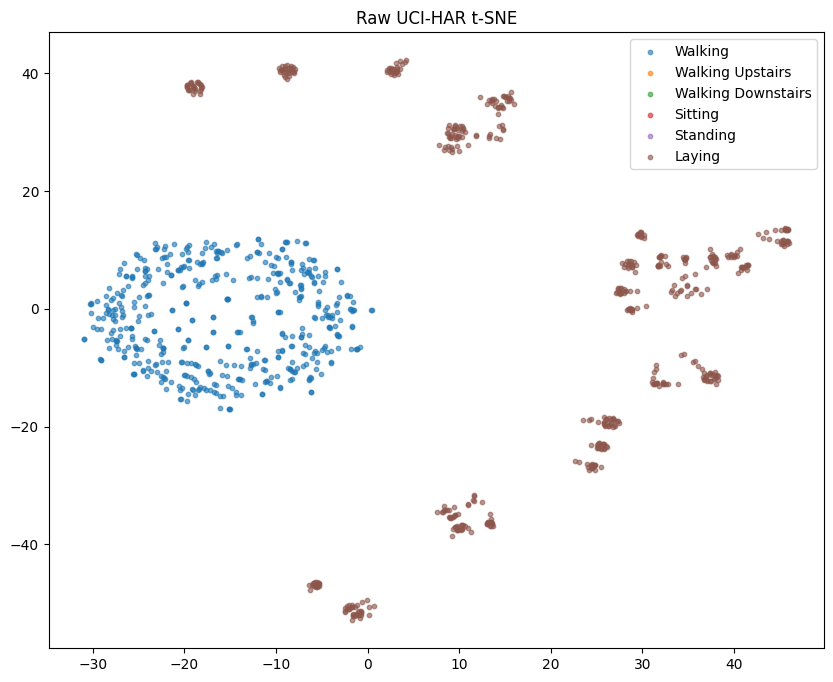

In [19]:
X_raw = X_test.reshape(X_test.shape[0], -1)

print(f"X_raw shape = {X_raw.shape}")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

embedding = tsne.fit_transform(X_raw)

activity_names = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

plt.figure(figsize=(10,8))

for i in range(6):
    idx = y_test == i

    plt.scatter(
        embedding[idx,0],
        embedding[idx,1],
        s=10,
        alpha=0.6,
        label=activity_names[i]
    )

plt.legend()
plt.title("Raw UCI-HAR t-SNE")
plt.show()

# **오토인코더 구현**

7x7 Conv1D로 구현을 해보자

In [75]:
class Autoencoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Conv1d(9, 32, kernel_size=7, stride=1, padding=3),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Conv1d(32, 64, kernel_size=7, stride=1, padding=3),
        nn.ReLU()
    )

    self.decoder = nn.Sequential(
        nn.Conv1d(64, 32, kernel_size=7, stride=1, padding=3),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Conv1d(32, 9, kernel_size=7, stride=1, padding=3)
    )

  def forward(self, x, return_feature=False):
    feat = self.encoder(x)
    logits = self.decoder(feat)

    if return_feature:
      return logits, feat
    return logits





In [76]:
def train(model, loader):
    model.train()

    total_loss = 0


    for X, y in loader:
        X = X.to(device)
        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, X)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)

    epoch_loss = total_loss / len(loader.dataset)
    val_loss = evaluate(model, val_loader)

    return epoch_loss, val_loss

def evaluate(model, loader):
    model.eval()

    total_loss = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            outputs = model(X)

            loss = criterion(outputs, X)
            total_loss += loss.item() * X.size(0)

    return total_loss / len(loader.dataset)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_profile(model):
  dummy_input = torch.randn(1, 9, 128).to(device)
  flops, params = profile(model, inputs=(dummy_input,))
  return flops, params

def benchmark(model, loader):
  model.eval()
  torch.cuda.synchronize()

  start = time.time()
  with torch.no_grad():
    for x, _ in loader:
      x = x.to(device)
      _ = model(x)

  torch.cuda.synchronize()
  end = time.time()

  return end - start

def extract_features(model, loader):
    model.eval()

    features = []
    labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)

            _, feat = model(X, return_feature=True)

            features.append(feat.cpu().numpy())
            labels.append(y.numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    return features, labels

In [77]:
model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
  train_loss, val_loss = train(model, train_loader)
  print(f"epoch {epoch+1}: train loss = {train_loss:.4f} | val loss = {val_loss:.4f}")

epoch 1: train loss = 0.0477 | val loss = 0.0135
epoch 2: train loss = 0.0131 | val loss = 0.0082
epoch 3: train loss = 0.0090 | val loss = 0.0061
epoch 4: train loss = 0.0068 | val loss = 0.0049
epoch 5: train loss = 0.0056 | val loss = 0.0041
epoch 6: train loss = 0.0046 | val loss = 0.0034
epoch 7: train loss = 0.0040 | val loss = 0.0031
epoch 8: train loss = 0.0037 | val loss = 0.0032
epoch 9: train loss = 0.0034 | val loss = 0.0026
epoch 10: train loss = 0.0031 | val loss = 0.0027
epoch 11: train loss = 0.0029 | val loss = 0.0024
epoch 12: train loss = 0.0027 | val loss = 0.0022
epoch 13: train loss = 0.0026 | val loss = 0.0020
epoch 14: train loss = 0.0024 | val loss = 0.0019
epoch 15: train loss = 0.0023 | val loss = 0.0020
epoch 16: train loss = 0.0021 | val loss = 0.0017
epoch 17: train loss = 0.0020 | val loss = 0.0018
epoch 18: train loss = 0.0019 | val loss = 0.0016
epoch 19: train loss = 0.0019 | val loss = 0.0015
epoch 20: train loss = 0.0018 | val loss = 0.0017
epoch 21:

In [78]:
model_profile = get_profile(model)
latency = benchmark(model, test_loader)

data = {
    "Model": ["CNN1D"],
    "Params (K)": int(model_profile[1]),
    "FLOPs (M)": model_profile[0],
    "Latency (ms)": latency,
}

df = pd.DataFrame(data)
df

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.


,Model,Params (K),FLOPs (M),Latency (ms)
0,CNN1D,32841,4186112.0,0.032381


In [79]:
from sklearn.metrics import classification_report
model.eval()

criterion_individual = nn.MSELoss(reduction='none')

test_losses = []
test_labels = []

with torch.no_grad():
  for X, y in test_loader:
    X = X.to(device)
    outputs = model(X)

    loss_matrix = criterion_individual(outputs, X)
    sample_losses = torch.mean(loss_matrix, dim=(1, 2)).cpu().numpy()

    test_losses.extend(sample_losses)
    test_labels.extend(y.numpy())

test_losses = np.array(test_losses)
test_labels = np.array(test_labels)

# laying_test_losses = test_losses[test_labels == 5]
# threshold = np.percentile(laying_test_losses, 99) # 정상 데이터의 99%를 커버하는 오차 크기

threshold = 0.05 # 그냥 대충 0.05이상 넘으면 다 이상치로 생각. 어차피 laying, walking은 classification이 너무 쉬워서 괜찮을듯.
print(f"설정된 이상치 탐지 Threshold: {threshold:.4f}\n")



설정된 이상치 탐지 Threshold: 0.0500



/tmp/ipykernel_893/2926002988.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


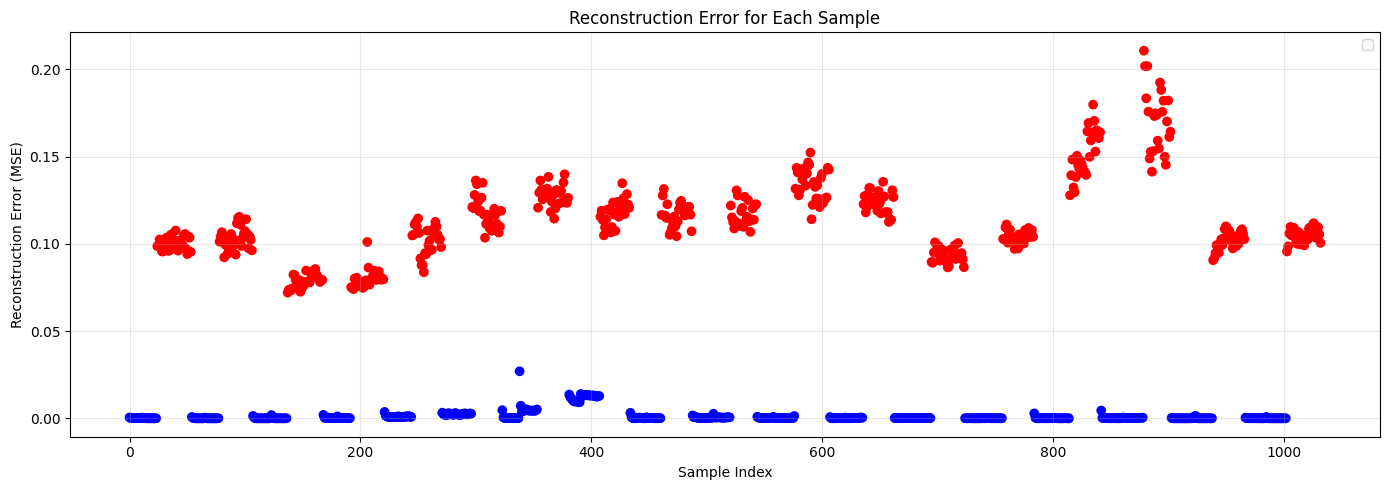

In [80]:
plt.figure(figsize=(14, 5))

colors = ['red' if loss > 0.05 else 'blue' for loss in test_losses]
plt.scatter(range(len(test_losses)), test_losses, color=colors)
plt.title('Reconstruction Error for Each Sample', fontsize=12)
plt.xlabel('Sample Index', fontsize=10)
plt.ylabel('Reconstruction Error (MSE)', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Classification Report ===
                   precision    recall  f1-score   support

WALKING (Anomaly)       1.00      1.00      1.00       496
  LAYING (Normal)       1.00      1.00      1.00       537

         accuracy                           1.00      1033
        macro avg       1.00      1.00      1.00      1033
     weighted avg       1.00      1.00      1.00      1033



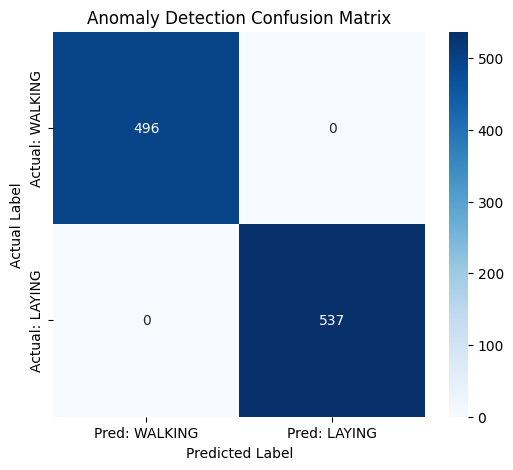

In [82]:
preds = np.where(test_losses > threshold, 0, 5)

cm = confusion_matrix(test_labels, preds, labels=[0, 5])

print("=== Classification Report ===")
print(classification_report(test_labels, preds, target_names=['WALKING (Anomaly)', 'LAYING (Normal)']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: WALKING', 'Pred: LAYING'],
            yticklabels=['Actual: WALKING', 'Actual: LAYING'])
plt.title('Anomaly Detection Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

(1033, 64, 128)


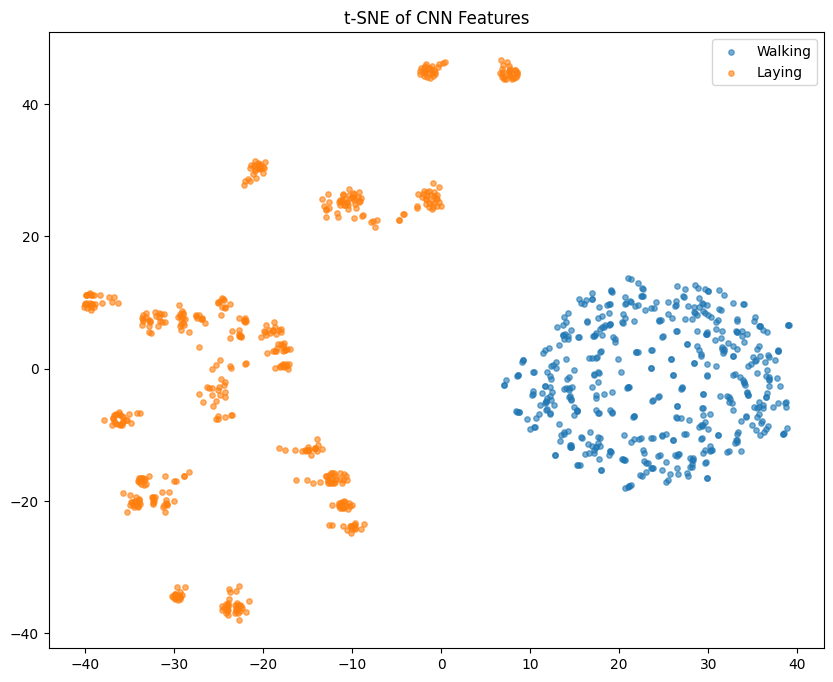

In [91]:
features, labels = extract_features(model, test_loader)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)
print(features.shape)
features = features.reshape(features.shape[0], -1)
embedding = tsne.fit_transform(features)


activity_names = {
  0: "Walking",
  5: "Laying"
}

plt.figure(figsize=(10,8))

for label_idx in np.unique(labels):
  if label_idx not in activity_names:
    continue

  idx = (labels == label_idx)

  plt.scatter(
    embedding[idx, 0],
    embedding[idx, 1],
    label=activity_names[label_idx], # 매핑된 이름 사용
    alpha=0.6,
    s=15
  )

plt.legend()
plt.title("t-SNE of CNN Features")
plt.show()